In [ ]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
import scipy.io as sio


sys.path.append('.')

from model import CropHSINet

print("Setup complete!")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")

Setup complete!
PyTorch version: 2.3.1+cpu
Device: CPU


In [2]:
def load_model(ckpt_path, device='cpu'):
    ckpt = torch.load(ckpt_path, map_location=device)
    model = CropHSINet(bands=ckpt['bands'], num_classes=ckpt['n_classes'], heads=4, c2d=64)
    model.load_state_dict(ckpt['model_state'])
    model.eval().to(device)
    meta = {'bands': ckpt['bands'], 'n_classes': ckpt['n_classes'], 'patch': ckpt.get('patch', 11)}
    return model, meta

def load_cube_from_mat(mat_path):
    m = sio.loadmat(mat_path)
    key, arr = max([(k, v) for k, v in m.items() if hasattr(v, 'ndim') and hasattr(v, 'size')], 
                   key=lambda kv: kv[1].size)
    cube = arr
    if cube.ndim == 3 and cube.shape[0] in (200, 270, 300) and cube.shape[2] < 20:
        cube = np.transpose(cube, (1, 2, 0))
    cube = cube.astype(np.float32)
    H, W, B = cube.shape
    bmin = cube.reshape(-1, B).min(axis=0)
    bmax = cube.reshape(-1, B).max(axis=0)
    brng = np.maximum(bmax - bmin, 1e-8)
    cube = (cube - bmin) / brng
    return cube

print("Functions defined!")

Functions defined!


In [6]:
MODEL_PATH = '../models/crop_classifier_final_longkou.pth'

print("Loading model...")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model, meta = load_model(MODEL_PATH, device)

print(f"Model loaded!")
print(f"  Classes: {meta['n_classes']}")
print(f"  Bands: {meta['bands']}")
print(f"  Patch size: {meta['patch']}")

Loading model...
Model loaded!
  Classes: 9
  Bands: 270
  Patch size: 11


In [8]:
DATA_PATH = '../sample_data/WHU_HI_LongKou.mat'

print("Loading scene...")
cube = load_cube_from_mat(DATA_PATH)

H, W, B = cube.shape
print(f"Scene loaded!")
print(f"  Height: {H}")
print(f"  Width: {W}")
print(f"  Bands: {B}")

if B != meta['bands']:
    print(f"ERROR: Scene has {B} bands but model needs {meta['bands']}!")
else:
    print("Scene and model are compatible!")

Loading scene...
Scene loaded!
  Height: 550
  Width: 400
  Bands: 270
Scene and model are compatible!


In [11]:
print("Running prediction (this takes a few minutes)...")

H, W, B = cube.shape
patch = meta['patch']
h = patch // 2
pred_map = -np.ones((H, W), dtype=np.int32)

 
centers = [(y, x) for y in range(h, H-h) for x in range(h, W-h)]
N = len(centers)
print(f"Total pixels to process: {N:,}")

batch_size = 256
device_torch = torch.device(device)

with torch.no_grad():
    for i in range(0, N, batch_size):
        end = min(i + batch_size, N)
        
        
        patches = []
        for j in range(i, end):
            y, x = centers[j]
            p = cube[y-h:y+h+1, x-h:x+h+1, :]
            patches.append(np.transpose(p, (2, 0, 1)))
        
        X = np.stack(patches, 0)[:, None]
        X = torch.from_numpy(X).float().to(device_torch)
        
        
        _, _, logits = model(X)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        
       
        for k, j in enumerate(range(i, end)):
            y, x = centers[j]
            pred_map[y, x] = preds[k]
        
         
        if (i // batch_size) % 10 == 0:
            print(f"  Progress: {end}/{N} ({end/N*100:.1f}%)")

print("Prediction complete!")

Running prediction (this takes a few minutes)...
Total pixels to process: 210,600
  Progress: 256/210600 (0.1%)
  Progress: 2816/210600 (1.3%)
  Progress: 5376/210600 (2.6%)
  Progress: 7936/210600 (3.8%)
  Progress: 10496/210600 (5.0%)
  Progress: 13056/210600 (6.2%)
  Progress: 15616/210600 (7.4%)
  Progress: 18176/210600 (8.6%)
  Progress: 20736/210600 (9.8%)
  Progress: 23296/210600 (11.1%)
  Progress: 25856/210600 (12.3%)
  Progress: 28416/210600 (13.5%)
  Progress: 30976/210600 (14.7%)
  Progress: 33536/210600 (15.9%)
  Progress: 36096/210600 (17.1%)
  Progress: 38656/210600 (18.4%)
  Progress: 41216/210600 (19.6%)
  Progress: 43776/210600 (20.8%)
  Progress: 46336/210600 (22.0%)
  Progress: 48896/210600 (23.2%)
  Progress: 51456/210600 (24.4%)
  Progress: 54016/210600 (25.6%)
  Progress: 56576/210600 (26.9%)
  Progress: 59136/210600 (28.1%)
  Progress: 61696/210600 (29.3%)
  Progress: 64256/210600 (30.5%)
  Progress: 66816/210600 (31.7%)
  Progress: 69376/210600 (32.9%)
  Progre

In [12]:
import os
os.makedirs('../output', exist_ok=True)

OUTPUT_PATH = '../output/pred_map.npy'
np.save(OUTPUT_PATH, pred_map)

print(f"✓ Saved prediction map to: {OUTPUT_PATH}")
print(f"  Shape: {pred_map.shape}")

✓ Saved prediction map to: ../output/pred_map.npy
  Shape: (550, 400)


CLASS DISTRIBUTION
Class  0:  34,001 pixels ( 16.1%)
Class  1:   8,307 pixels (  3.9%)
Class  2:   3,204 pixels (  1.5%)
Class  3:  62,652 pixels ( 29.7%)
Class  4:   4,248 pixels (  2.0%)
Class  5:  12,887 pixels (  6.1%)
Class  6:  67,392 pixels ( 32.0%)
Class  7:  11,513 pixels (  5.5%)
Class  8:   6,396 pixels (  3.0%)

✓ Visualization saved to: ../output/classification_map.png


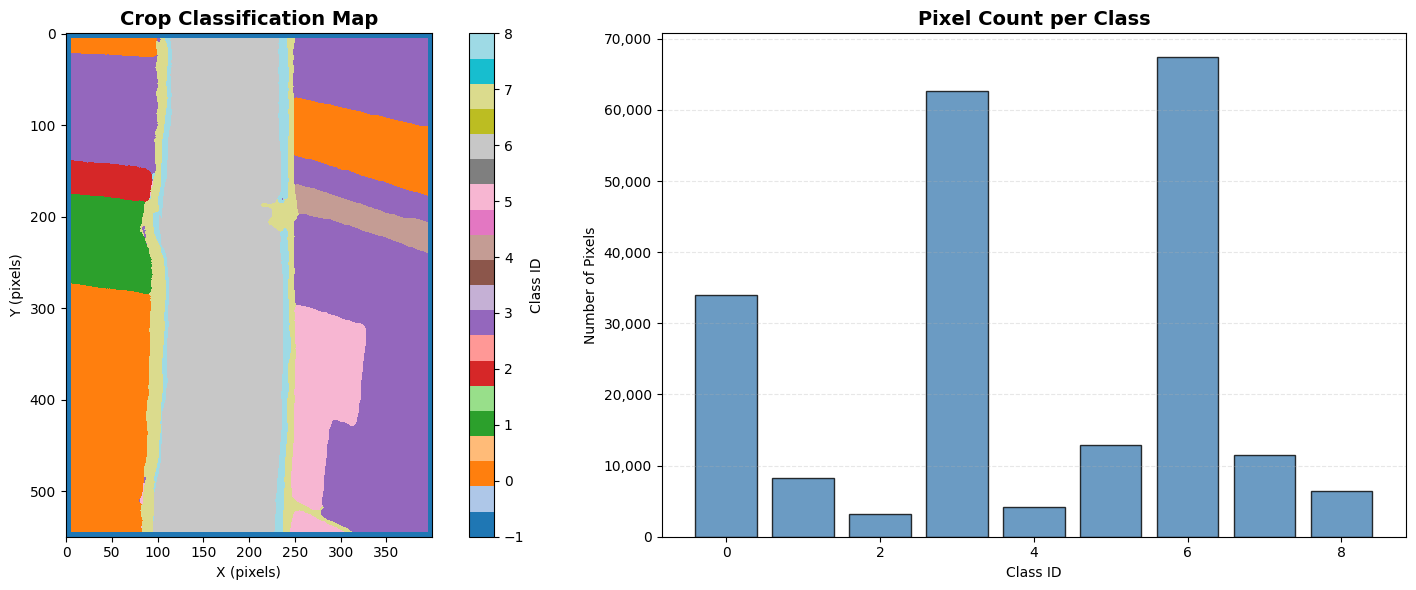

In [16]:
 
unique, counts = np.unique(pred_map[pred_map >= 0], return_counts=True)
total = counts.sum()

 
print("CLASS DISTRIBUTION")
 
for cls, cnt in zip(unique, counts):
    percentage = (cnt/total) * 100
    print(f"Class {cls:2d}: {cnt:7,} pixels ({percentage:5.1f}%)")
 

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Map visualization
im = axes[0].imshow(pred_map, cmap='tab20', interpolation='nearest')
axes[0].set_title('Crop Classification Map', fontsize=14, fontweight='bold')
axes[0].set_xlabel('X (pixels)')
axes[0].set_ylabel('Y (pixels)')
plt.colorbar(im, ax=axes[0], label='Class ID')

# Bar chart
axes[1].bar(unique, counts, color='steelblue', edgecolor='black', alpha=0.8)
axes[1].set_title('Pixel Count per Class', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Class ID')
axes[1].set_ylabel('Number of Pixels')
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

# Format numbers on y-axis
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../output/classification_map.png', dpi=150, bbox_inches='tight')
print(f"\n✓ Visualization saved to: ../output/classification_map.png")
plt.show()